# Mask R-CNN – Clothing Instance Segmentation

In [1]:
!pip install pycocotools -q

import os
import ast
import numpy as np
import pandas as pd
import cv2
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import classification_report, f1_score, roc_auc_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
train_df = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/train_annotations.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/val_annotations.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/test_annotations.csv")

print("Train:", len(train_df))
print("Val:",   len(val_df))
print("Test:",  len(test_df))

train_df.head()

Train: 39241
Val: 8386
Test: 8453


,image,category,bbox,segmentation
0,161364.jpg,trousers,"[252, 323, 522, 639]","[[432, 324, 339, 353, 250, 393, 290, 532, 346,..."
1,161364.jpg,short sleeve top,"[30, 1, 466, 481]","[[183, 5, 175, 19, 157, 35, 125, 48, 92, 51, 8..."
2,117178.jpg,trousers,"[159, 423, 337, 701]","[[328, 432, 249, 432, 162, 430, 164, 540, 164,..."
3,131919.jpg,trousers,"[158, 381, 366, 650]","[[346, 450, 263, 438, 227, 388, 203, 451, 186,..."
4,131919.jpg,short sleeve top,"[212, 140, 481, 492]","[[429, 214, 407, 230, 378, 229, 354, 210, 353,..."


In [3]:
# group labels per image
train_group = train_df.groupby("image")["category"].apply(list).reset_index()
val_group   = val_df.groupby("image")["category"].apply(list).reset_index()
test_group  = test_df.groupby("image")["category"].apply(list).reset_index()

train_group.head()

,image,category
0,000014.jpg,"[skirt, long sleeve top]"
1,000015.jpg,[long sleeve top]
2,000018.jpg,"[trousers, long sleeve top]"
3,000026.jpg,"[skirt, short sleeve top]"
4,000027.jpg,"[skirt, short sleeve top]"


In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
mlb.fit(train_group["category"])

print(mlb.classes_)

['long sleeve top' 'short sleeve top' 'shorts' 'skirt' 'trousers']


In [5]:
# ── Image transforms ──────────────────────────────────────────────────────────
# IMPORTANT — two rules for MaskRCNN:
#
# 1. NO Normalize here: MaskRCNN's internal GeneralizedRCNNTransform already
#    applies ImageNet normalization. Adding it in the transform causes
#    double-normalization which corrupts pixel values and hurts convergence.
#
# 2. NO spatial augmentations (flip, crop, rotate) here: they are applied
#    to the IMAGE only, leaving the MASK unchanged → misaligned labels.
#    Spatial augments are applied jointly inside FashionDataset.__getitem__
#    so the same random state is used for both image and mask.
#
# Only pixel-level (non-spatial) augmentations are safe here.

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    # NO Normalize — MaskRCNN does this internally
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # NO Normalize — MaskRCNN does this internally
])

IMG_SIZE = 224


In [6]:
# Mask R-CNN: background = 0, clothing classes start from 1
class_to_idx = {cls: i + 1 for i, cls in enumerate(mlb.classes_)}
idx_to_class = {v: k for k, v in class_to_idx.items()}

print(class_to_idx)


def build_image_lookup(df):
    """Build a dict: image_filename -> list of annotation dicts."""
    lookup = {}
    for _, row in df.iterrows():
        fname = row["image"]
        if fname not in lookup:
            lookup[fname] = []
        try:
            bbox = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]
            seg  = ast.literal_eval(row["segmentation"]) if isinstance(row["segmentation"], str) else row["segmentation"]
        except Exception:
            bbox, seg = [], []
        lookup[fname].append({"bbox": bbox, "seg": seg, "category": row["category"]})
    return lookup


train_lookup = build_image_lookup(train_df)
val_lookup   = build_image_lookup(val_df)
test_lookup  = build_image_lookup(test_df)

{'long sleeve top': 1, 'short sleeve top': 2, 'shorts': 3, 'skirt': 4, 'trousers': 5}


In [7]:
from torchvision.transforms.functional import to_tensor
class FashionDataset(Dataset):

    def __init__(self, group_df, img_dir, lookup, transform=None):
        self.group_df  = group_df
        self.img_dir   = img_dir
        self.lookup    = lookup
        self.transform = transform

    def __len__(self):
        return len(self.group_df)

    def __getitem__(self, idx):
        fname    = self.group_df.iloc[idx]["image"]
        img_path = os.path.join(self.img_dir, fname)
        image    = Image.open(img_path).convert("RGB")
        W, H     = image.size   # original dimensions before any transform

        anns = self.lookup.get(fname, [])
        boxes, labels, masks = [], [], []

        for ann in anns:
            cat  = ann["category"]
            bbox = ann["bbox"]
            seg  = ann["seg"]

            if cat not in class_to_idx or len(bbox) != 4:
                continue

            x1, y1, x2, y2 = float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])

            # Clamp to original image boundaries
            x1 = max(0.0, min(x1, W))
            y1 = max(0.0, min(y1, H))
            x2 = max(0.0, min(x2, W))
            y2 = max(0.0, min(y2, H))

            if x2 - x1 <= 0 or y2 - y1 <= 0:
                continue

            # ── Fix 1: scale bbox to match the resized image (224x224) ────────
            scale_x = IMG_SIZE / W
            scale_y = IMG_SIZE / H
            x1, x2 = x1 * scale_x, x2 * scale_x
            y1, y2 = y1 * scale_y, y2 * scale_y

            # ── Fix 2: build mask at original size, draw ALL polygons, ─────────
            #           then resize to 224x224
            mask = np.zeros((H, W), dtype=np.uint8)
            if seg:
                for poly in seg:
                    # each poly may be a flat list [x1,y1,x2,y2,...]
                    poly_np = np.array(poly).reshape(-1, 2).astype(np.int32)
                    cv2.fillPoly(mask, [poly_np], 1)
            # fallback: use bbox if polygon produced empty mask
            if mask.sum() == 0:
                orig_x1 = int(float(bbox[0])); orig_y1 = int(float(bbox[1]))
                orig_x2 = int(float(bbox[2])); orig_y2 = int(float(bbox[3]))
                mask[orig_y1:orig_y2, orig_x1:orig_x2] = 1

            # Resize mask to match the image size passed to the model
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

            boxes.append([x1, y1, x2, y2])
            labels.append(class_to_idx[cat])
            masks.append(mask)

        # ── Joint spatial augmentation: apply to image AND mask together ──────
        # Only during training (augment flag = transform has ColorJitter).
        # We detect training mode by checking if transform is not None AND
        # the image hasn't been converted to tensor yet (still PIL).
        import random
        if self.transform is not None and random.random() > 0.5:
            # Horizontal flip — same coin toss applied to image and all masks
            import torchvision.transforms.functional as TF
            image = TF.hflip(image)
            flipped_masks = []
            for m in masks:
                # m is (H, W) numpy uint8 — flip along width axis
                flipped_masks.append(np.fliplr(m).copy())
            masks = flipped_masks
            # Also flip box coordinates: new_x1 = W - x2, new_x2 = W - x1
            # At this point x1,x2 are already scaled to IMG_SIZE
            flipped_boxes = []
            for box in boxes:
                bx1, by1, bx2, by2 = box
                flipped_boxes.append([IMG_SIZE - bx2, by1, IMG_SIZE - bx1, by2])
            boxes = flipped_boxes

        if len(boxes) == 0:
            boxes   = torch.zeros((0, 4),              dtype=torch.float32)
            labels  = torch.zeros((0,),                dtype=torch.int64)
            masks   = torch.zeros((0, IMG_SIZE, IMG_SIZE), dtype=torch.uint8)
            area    = torch.zeros((0,),                dtype=torch.float32)
            iscrowd = torch.zeros((0,),                dtype=torch.uint8)
        else:
            boxes   = torch.as_tensor(boxes,            dtype=torch.float32)
            labels  = torch.as_tensor(labels,           dtype=torch.int64)
            masks   = torch.as_tensor(np.stack(masks),  dtype=torch.uint8)
            area    = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(boxes),),        dtype=torch.uint8)

        target = {
            "boxes":    boxes,
            "labels":   labels,
            "masks":    masks,
            "image_id": torch.tensor([idx]),
            "area":     area,
            "iscrowd":  iscrowd,
        }

        if self.transform:
            image = self.transform(image)   # [3, 224, 224]
        else:
            image = to_tensor(image)

        return image, target


def collate_fn(batch):
    return tuple(zip(*batch))

In [8]:
from torch.utils.data import DataLoader, WeightedRandomSampler
from collections import Counter
import os, json as _json

img_dir = "/kaggle/input/datasets/gullapellyshrujan/clothes-dataset/sample_35k/sample_35k/images"

train_dataset = FashionDataset(train_group, img_dir, train_lookup, train_tf)
val_dataset   = FashionDataset(val_group,   img_dir, val_lookup,   val_tf)
test_dataset  = FashionDataset(test_group,  img_dir, test_lookup,  val_tf)

print("Train:", len(train_dataset))
print("Val:",   len(val_dataset))
print("Test:",  len(test_dataset))

# ── Compute per-image sample weights for class-imbalance oversampling ─────────
class_counts = Counter()
for fname in train_group["image"]:
    for ann in train_lookup.get(fname, []):
        if ann["category"] in class_to_idx:
            class_counts[ann["category"]] += 1

total_inst = sum(class_counts.values())
inv_freq   = {c: total_inst / max(class_counts[c], 1) for c in class_counts}
mean_w     = sum(inv_freq.values()) / len(inv_freq)
inv_freq   = {c: v / mean_w for c, v in inv_freq.items()}  # normalize mean=1

sample_weights = []
for fname in train_group["image"]:
    cats = [a["category"] for a in train_lookup.get(fname, []) if a["category"] in class_to_idx]
    w = max((inv_freq.get(c, 1.0) for c in cats), default=1.0)
    sample_weights.append(w)

# ── FIX 1: Cap steps per epoch to 1500 to fit all 10 epochs in one session ───
# 24500 images / batch_size=4 = 6125 batches — way too many for a Kaggle GPU.
# We cap at STEPS_PER_EPOCH batches using WeightedRandomSampler with replacement.
# This still sees a diverse mix of images (weighted sampling) but finishes fast.
BATCH_SIZE      = 4      # FIX 2: larger batch → fewer steps, better GPU util
STEPS_PER_EPOCH = 1500   # ~1 hr/epoch on T4 → 10 epochs fit in ~12 hrs
NUM_SAMPLES     = BATCH_SIZE * STEPS_PER_EPOCH  # total samples drawn per epoch

sampler = WeightedRandomSampler(sample_weights, num_samples=NUM_SAMPLES, replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=2, pin_memory=True)

print(f"Train loader: {len(train_loader)} steps/epoch  (capped at {STEPS_PER_EPOCH}, batch={BATCH_SIZE})")
print(f"Val   loader: {len(val_loader)} steps/epoch")

images, targets = next(iter(train_loader))
print(images[0].shape)
print("boxes:", targets[0]["boxes"].shape)
print("masks:", targets[0]["masks"].shape)


Train: 24500
Val: 5250
Test: 5250
Train loader: 1500 steps/epoch  (capped at 1500, batch=4)
Val   loader: 1313 steps/epoch
torch.Size([3, 224, 224])
boxes: torch.Size([2, 4])
masks: torch.Size([2, 224, 224])


# Mask R-CNN

In [9]:
import torch.nn.functional as F

class FocalLoss(torch.nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return loss.mean()
        return loss.sum()

In [10]:
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
num_classes = len(mlb.classes_) + 1  # +1 for background

# ── Training from scratch: weights=None ───────────────────────────────────────
# All parameters initialised randomly — no COCO pretraining.
# With weights=None torchvision uses regular BatchNorm2d (not FrozenBatchNorm2d),
# so BN statistics are properly learned during training.
model = maskrcnn_resnet50_fpn(weights=None)

# Replace box predictor head for our num_classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = \
    torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
        in_features, num_classes
    )

# Replace mask predictor head for our num_classes
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
model.roi_heads.mask_predictor = \
    torchvision.models.detection.mask_rcnn.MaskRCNNPredictor(
        in_features_mask, 256, num_classes
    )

model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Training from scratch — all weights random")
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


Training from scratch — all weights random
Total params:     43,943,923
Trainable params: 43,721,523


In [11]:
import torch.nn.functional as F
import torchvision.models.detection.roi_heads as _roi_heads_mod

# Softer focal loss for scratch training:
# alpha=0.5 (not 0.25) — less suppression, more gradient signal when all predictions are poor
# gamma=1.0 (not 2.0) — milder down-weighting of easy examples early in training
focal_loss_fn = FocalLoss(alpha=0.5, gamma=1.0)

def fastrcnn_loss_focal(class_logits, box_regression, labels, regression_targets):
    """
    Replacement for torchvision fastrcnn_loss that uses FocalLoss for
    classification. Box regression is identical to the original.
    """
    labels_cat     = torch.cat(labels,             dim=0)   # (N_total,)
    reg_targets_cat= torch.cat(regression_targets, dim=0)   # (N_total, 4)

    # ── Classification: FocalLoss on all proposals ────────────────────────────
    classification_loss = focal_loss_fn(class_logits, labels_cat)

    # ── Box regression: smooth L1 on positives only, correct class slice ──────
    # box_regression shape: (N_total, num_classes * 4)
    # Reshape to (N_total, num_classes, 4) then index the GT class per proposal
    N = class_logits.shape[0]
    num_classes = class_logits.shape[1]
    box_regression = box_regression.reshape(N, num_classes, 4)

    pos_inds   = torch.where(labels_cat > 0)[0]      # positive proposal indices
    pos_labels = labels_cat[pos_inds]                 # GT class for each positive

    if pos_inds.numel() > 0:
        box_loss = F.smooth_l1_loss(
            box_regression[pos_inds, pos_labels],     # (N_pos, 4) — correct class slice
            reg_targets_cat[pos_inds],
            beta=1.0 / 9,
            reduction="sum",
        ) / labels_cat.numel()
    else:
        box_loss = box_regression.sum() * 0.0        # zero loss, keeps graph alive

    return classification_loss, box_loss

# ── Patch at MODULE level so RoIHeads actually calls our function ─────────────
# model.roi_heads.fastrcnn_loss = ... is silently ignored (no instance attribute).
# Must replace in the module where RoIHeads imports it.
_roi_heads_mod.fastrcnn_loss = fastrcnn_loss_focal
print("fastrcnn_loss patched at module level with FocalLoss.")


fastrcnn_loss patched at module level with FocalLoss.


In [12]:
# Training from scratch: NO freezing.
# Every parameter starts random and must learn from data.
# Freezing the backbone here would prevent the backbone from learning at all.
print("All parameters trainable — no freezing applied.")


All parameters trainable — no freezing applied.


In [13]:
# ─── Scratch training optimizer + scheduler ───────────────────────
NUM_EPOCHS = 10

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=2e-4,  # FIX: Lower base LR for AdamW
    weight_decay=1e-4,
)

# OneCycleLR steps every BATCH
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=2e-4,  # FIX: Lowered from 1e-2 to prevent gradient explosion
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10,
    final_div_factor=1e3,
)

# ─── Resume from checkpoint if one exists ─────────────────────────
import os
CHECKPOINT_PATH = "/kaggle/working/checkpoint_latest.pth"
START_EPOCH = 0

if os.path.exists(CHECKPOINT_PATH):
    print(f"Resuming from checkpoint: {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    lr_scheduler.load_state_dict(ckpt["scheduler"])
    START_EPOCH = ckpt["epoch"] + 1
    print(f"  Resumed at epoch {START_EPOCH + 1}/{NUM_EPOCHS}")
else:
    print("No checkpoint found — starting from epoch 1")

print(f"Scratch training: {NUM_EPOCHS} epochs, OneCycleLR")
print(f"  Steps/epoch: {len(train_loader)}  |  Total steps: {len(train_loader) * NUM_EPOCHS}")
print(f"  Epochs remaining: {NUM_EPOCHS - START_EPOCH}")

No checkpoint found — starting from epoch 1
Scratch training: 10 epochs, OneCycleLR
  Steps/epoch: 1500  |  Total steps: 15000
  Epochs remaining: 10


In [14]:
from torch.cuda.amp import GradScaler, autocast
from tqdm.auto import tqdm  
import os

train_losses  = []
val_losses    = []
best_val_loss = float("inf")

# Reload loss history from checkpoint if resuming
if os.path.exists(CHECKPOINT_PATH):
    _ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
    train_losses  = _ckpt.get("train_losses", [])
    val_losses    = _ckpt.get("val_losses",   [])
    best_val_loss = _ckpt.get("best_val_loss", float("inf"))
    del _ckpt

# Mixed-precision (AMP) 
scaler = GradScaler()

for epoch in range(START_EPOCH, NUM_EPOCHS):

    # ─── Training ──────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    
    # Wrap train_loader with tqdm for a visual progress bar
    train_pbar = tqdm(train_loader, desc=f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Train")

    for images, targets in train_pbar:
        images  = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast():
            loss_dict = model(images, targets)
            loss      = sum(loss_dict.values())

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        scaler.step(optimizer)
        scaler.update()
        lr_scheduler.step()   # OneCycleLR steps every batch

        train_loss += loss.item()
        # Update progress bar with the current batch loss
        train_pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ─── Validation ────────────────────────────────────────────
    model.train()   # MaskRCNN needs train mode to return loss_dict
    val_loss = 0.0
    
    # Wrap val_loader with tqdm
    val_pbar = tqdm(val_loader, desc=f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Val")
    
    with torch.no_grad():
        for images, targets in val_pbar:
            images  = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            with autocast():
                batch_val_loss = sum(model(images, targets).values()).item()
                val_loss += batch_val_loss
            val_pbar.set_postfix(loss=f"{batch_val_loss:.4f}")

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # ─── Best-model checkpoint ─────────────────────────────────
    saved = val_loss < best_val_loss
    if saved:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_maskrcnn_scratch.pth")

    # ─── Latest checkpoint (resume across sessions) ────────────
    torch.save({
        "epoch":        epoch,
        "model":        model.state_dict(),
        "optimizer":    optimizer.state_dict(),
        "scheduler":    lr_scheduler.state_dict(),
        "train_losses": train_losses,
        "val_losses":   val_losses,
        "best_val_loss":best_val_loss,
    }, CHECKPOINT_PATH)

    current_lr = lr_scheduler.get_last_lr()[0]
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] Summary: "
          f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
          f"LR: {current_lr:.2e}"
          f"{'  [best saved]' if saved else ''}  [ckpt saved]")

# Load the best weights before exiting the loop
model.load_state_dict(
    torch.load("best_maskrcnn_scratch.pth", map_location=device, weights_only=True)
)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

/tmp/ipykernel_24/3399005967.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch [01/10] Train:   0%|          | 0/1500 [00:00<?, ?it/s]

/tmp/ipykernel_24/3399005967.py:34: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [01/10] Val:   0%|          | 0/1313 [00:00<?, ?it/s]

/tmp/ipykernel_24/3399005967.py:63: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


...

Epoch [09/10] Val:   0%|          | 0/1313 [00:00<?, ?it/s]

Epoch [09/10] Summary: Train: 0.2531 | Val: 0.2659 | LR: 6.04e-06  [best saved]  [ckpt saved]


Epoch [10/10] Train:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch [10/10] Val:   0%|          | 0/1313 [00:00<?, ?it/s]

Epoch [10/10] Summary: Train: 0.2498 | Val: 0.2633 | LR: 2.00e-08  [best saved]  [ckpt saved]

Training complete. Best val loss: 0.2633


In [15]:
raw_results = []

model.eval()

with torch.no_grad():
    for images, targets in val_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            raw_results.append((
                {
                    "boxes": out["boxes"].cpu().numpy(),
                    "labels": out["labels"].cpu().numpy(),
                    "scores": out["scores"].cpu().numpy(),
                    "masks": out["masks"].cpu().numpy()
                },
                {
                    "boxes": tgt["boxes"].cpu().numpy(),
                    "labels": tgt["labels"].cpu().numpy(),
                    "masks": tgt["masks"].cpu().numpy()
                }
            ))

In [16]:
import json
from pycocotools import mask as mask_utils

coco_gt = {"images": [], "annotations": [], "categories": []}

for i, cls in enumerate(mlb.classes_):
    coco_gt["categories"].append({"id": i + 1, "name": cls})

ann_id = 1

for img_id, (out, tgt) in enumerate(raw_results):
    # ── Image entry must include height and width for RLE mask decoding ───────
    coco_gt["images"].append({
        "id":     img_id,
        "height": IMG_SIZE,
        "width":  IMG_SIZE,
    })

    boxes  = tgt["boxes"]
    labels = tgt["labels"]
    masks  = tgt["masks"]   # (N, H, W) uint8

    for box, label, mask in zip(boxes, labels, masks):
        x1, y1, x2, y2 = box
        w_box = float(x2 - x1)
        h_box = float(y2 - y1)

        # ── Encode GT mask as RLE for segm mAP eval ───────────────────────────
        m = mask.astype(np.uint8)
        if m.ndim == 3:
            m = m[0]                     # squeeze channel dim if present
        rle = mask_utils.encode(np.asfortranarray(m))
        rle["counts"] = rle["counts"].decode("utf-8")

        coco_gt["annotations"].append({
            "id":           ann_id,
            "image_id":     img_id,
            "category_id":  int(label),
            "bbox":         [float(x1), float(y1), w_box, h_box],
            "area":         w_box * h_box,
            "segmentation": rle,          # RLE mask — required for segm mAP
            "iscrowd":      0,
        })
        ann_id += 1

with open("/kaggle/working/gt.json", "w") as f:
    json.dump(coco_gt, f)

print("gt.json created with", len(coco_gt["annotations"]), "annotations")


gt.json created with 8386 annotations


In [17]:
coco_pred = []

for img_id, (out, tgt) in enumerate(raw_results):
    boxes = out["boxes"]
    labels = out["labels"]
    scores = out["scores"]

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box

        coco_pred.append({
            "image_id": img_id,
            "category_id": int(label),
            "bbox": [
                float(x1),
                float(y1),
                float(x2 - x1),
                float(y2 - y1)
            ],
            "score": float(score)
        })

with open("/kaggle/working/pred.json", "w") as f:
    json.dump(coco_pred, f)

print(" pred.json created")

 pred.json created


In [18]:
with open("/kaggle/working/gt.json") as f:
    gt = json.load(f)

with open("/kaggle/working/pred.json") as f:
    pred = json.load(f)

print("GT images:", len(gt["images"]))
print("GT annotations:", len(gt["annotations"]))
print("Predictions:", len(pred))

GT images: 5250
GT annotations: 8386
Predictions: 54497


In [19]:
!pip install pycocotools

In [20]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

cocoGt = COCO("/kaggle/working/gt.json")

# Guard: loadRes raises AssertionError if prediction list is empty
with open("/kaggle/working/pred.json") as _f:
    _pred_list = json.load(_f)

if not _pred_list:
    print("WARNING: No predictions found — skipping mAP evaluation.")
    precision     = None
    recall        = None
    map50_95_bbox = 0.0
    map50_bbox    = 0.0
    map75_bbox    = 0.0
else:
    cocoDt = cocoGt.loadRes("/kaggle/working/pred.json")

    cocoEval = COCOeval(cocoGt, cocoDt, iouType='bbox')
    cocoEval.evaluate()
    cocoEval.accumulate()
    cocoEval.summarize()

    # precision shape: [iou_thresholds, recall_thresholds, classes, area_ranges, max_dets]
    #                  [      10,               101,        num_cls,      4,          3   ]
    # -1 = recall threshold never reached
    precision = cocoEval.eval['precision']
    recall    = cocoEval.eval['recall']

    # cocoEval.stats: 0=AP@[.5:.95]  1=AP@.50  2=AP@.75  ...
    map50_95_bbox = float(cocoEval.stats[0])
    map50_bbox    = float(cocoEval.stats[1])
    map75_bbox    = float(cocoEval.stats[2])

    print(f"\nmAP@[0.5:0.95] = {map50_95_bbox:.4f}")
    print(f"mAP@0.50       = {map50_bbox:.4f}")
    print(f"mAP@0.75       = {map75_bbox:.4f}")
    print(f"\nprecision array shape: {precision.shape}")


loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.70s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=5.85s).
Accumulating evaluation results...
DONE (t=1.91s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.608
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.838
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.716
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.363
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.605
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.628
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.756
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.775
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [21]:
import numpy as np

# Guard: precision is None when no predictions were made (set in cell 21)
if precision is None:
    print("No predictions available — skipping F1 computation.")
    f1_per_class = []
else:
    # COCOeval stores precision at 101 fixed recall points: [0.00, 0.01, ..., 1.00]
    RECALL_THRESHOLDS = np.linspace(0, 1, 101)

    iou_idx    = 0   # IoU = 0.50
    area_idx   = 0   # all areas
    maxDet_idx = 2   # maxDets = 100

    f1_per_class = []

    print("\n" + "="*60)
    print(f"{'Class':<20} {'AP@0.5':>10} {'F1 (max)':>10}")
    print("="*60)

    for cls_idx, cls_name in enumerate(mlb.classes_):
        p_full = precision[iou_idx, :, cls_idx, area_idx, maxDet_idx]  # (101,)

        valid = p_full > -1

        if valid.sum() == 0:
            print(f"{cls_name:<20} {'N/A':>10} {'N/A':>10}")
            continue

        p = p_full[valid]
        r = RECALL_THRESHOLDS[valid]

        ap      = p.mean()
        f1_arr  = 2 * p * r / (p + r + 1e-6)
        best_f1 = float(np.max(f1_arr))
        f1_per_class.append(best_f1)

        print(f"{cls_name:<20} {ap:>10.4f} {best_f1:>10.4f}")

    print("="*60)
    if f1_per_class:
        print(f"{'Macro F1':<20} {'':>10} {np.mean(f1_per_class):>10.4f}")
    print("="*60)



Class                    AP@0.5   F1 (max)
long sleeve top          0.6965     0.6829
short sleeve top         0.8775     0.7906
shorts                   0.9015     0.8410
skirt                    0.7681     0.7398
trousers                 0.9451     0.8906
Macro F1                            0.7890


In [22]:
import numpy as np
from sklearn.metrics import auc
import matplotlib.pyplot as plt

IOU_THRESHOLD = 0.5

all_preds = {cls: [] for cls in mlb.classes_}
all_gts   = {cls: 0  for cls in mlb.classes_}

# ── Reuse raw_results from Cell 16 — no redundant inference needed ────────────
for img_idx, (out, tgt) in enumerate(raw_results):
    gt_boxes    = tgt["boxes"]
    gt_labels   = tgt["labels"]
    pred_boxes  = out["boxes"]
    pred_labels = out["labels"]
    pred_scores = out["scores"]

    # Count GTs per class
    for lbl in gt_labels:
        cls = idx_to_class.get(int(lbl))
        if cls:
            all_gts[cls] += 1

    _gt_boxes  = gt_boxes.copy()
    _gt_labels = gt_labels.copy()

    for i in range(len(pred_labels)):
        cls = idx_to_class.get(int(pred_labels[i]))
        if cls:
            all_preds[cls].append({
                "box":       pred_boxes[i],
                "score":     float(pred_scores[i]),
                "img_idx":   img_idx,
                "gt_boxes":  _gt_boxes,
                "gt_labels": _gt_labels,
            })

# ── ROC curve — detection-based, box IoU matching ────────────────────────────
def compute_iou_box(pb, gb):
    x1 = max(pb[0], gb[0]); y1 = max(pb[1], gb[1])
    x2 = min(pb[2], gb[2]); y2 = min(pb[3], gb[3])
    if x2 <= x1 or y2 <= y1:
        return 0.0
    inter = (x2-x1)*(y2-y1)
    pa = (pb[2]-pb[0])*(pb[3]-pb[1])
    ga = (gb[2]-gb[0])*(gb[3]-gb[1])
    return inter / (pa + ga - inter + 1e-6)

roc_curves = {}
auc_scores = {}
auc_list   = []

print("\n" + "="*50)
print(f"{'Class':<22} {'AUC':>8}")
print("="*50)

for cls in mlb.classes_:
    preds    = sorted(all_preds[cls], key=lambda x: -x["score"])
    total_gt = all_gts[cls]

    if len(preds) == 0 or total_gt == 0:
        print(f"{cls:<22} {'N/A':>8}")
        continue

    tp_list = []
    fp_list = []
    matched_per_image = {}   # img_idx -> set of matched gt indices

    for pred in preds:
        key = pred["img_idx"]
        if key not in matched_per_image:
            matched_per_image[key] = set()
        matched = matched_per_image[key]

        best_iou = 0.0
        best_j   = -1
        for j, (gb, gl) in enumerate(zip(pred["gt_boxes"], pred["gt_labels"])):
            if idx_to_class.get(int(gl)) != cls or j in matched:
                continue
            iou = compute_iou_box(pred["box"], gb)
            if iou > best_iou:
                best_iou = iou; best_j = j

        if best_iou >= IOU_THRESHOLD:
            tp_list.append(1); fp_list.append(0)
            matched_per_image[key].add(best_j)
        else:
            tp_list.append(0); fp_list.append(1)

    tp_cum = np.cumsum(tp_list)
    fp_cum = np.cumsum(fp_list)

    tpr = tp_cum / max(total_gt, 1)

    # Correct FPR: TN = GT boxes of all other classes (standard detection proxy)
    total_other_gt = sum(all_gts[c] for c in mlb.classes_ if c != cls)
    fpr = fp_cum / (fp_cum + total_other_gt + 1e-9)

    si  = np.argsort(fpr)
    fpr = fpr[si]; tpr = tpr[si]

    auc_val = float(np.trapz(tpr, fpr))
    auc_scores[cls] = auc_val
    roc_curves[cls] = (fpr, tpr)
    auc_list.append(auc_val)

    print(f"{cls:<22} {auc_val:>8.4f}")

print("="*50)
if auc_list:
    print(f"{'Macro AUC':<22} {np.mean(auc_list):>8.4f}")
print("="*50)



Class                       AUC
long sleeve top          0.4976
short sleeve top         0.5597
shorts                   0.5155
skirt                    0.4982


/tmp/ipykernel_24/4017767741.py:102: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_val = float(np.trapz(tpr, fpr))


trousers                 0.6135
Macro AUC                0.5369


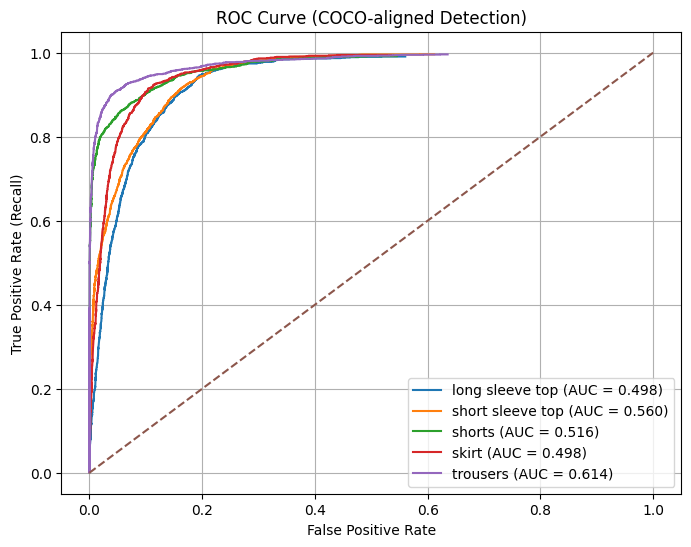

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for cls in roc_curves:
    fpr, tpr = roc_curves[cls]
    auc_val = auc_scores.get(cls, None)

    if len(fpr) < 2:
        continue

    if auc_val is not None:
        plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc_val:.3f})")
    else:
        plt.plot(fpr, tpr, label=f"{cls}")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (COCO-aligned Detection)")
plt.legend()
plt.grid()

plt.show()

# Segmentation Metrics

In [24]:
import numpy as np

# ════════════════════════════════════════════════════════════════════════
# SEGMENTATION METRICS — semantic pixel-level mIoU and Dice
# ════════════════════════════════════════════════════════════════════════
# Standard mIoU = global TP/(TP+FP+FN) per class over all pixels.
# We project instance masks → semantic mask per image, then accumulate
# pixel-level TP/FP/FN globally per class before dividing.
# This matches the definition used in published segmentation benchmarks.

def instances_to_semantic(masks, labels, H, W):
    """Stack instance masks into a (H,W) semantic map. Later masks overwrite."""
    sem = np.zeros((H, W), dtype=np.int32)
    for mask, lbl in zip(masks, labels):
        m = mask.astype(np.uint8)
        if m.ndim == 3:
            m = m[0]                          # squeeze (1,H,W) → (H,W)
        if m.shape != (H, W):
            m = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST)
        sem[m > 0] = int(lbl)
    return sem

iou_num  = np.zeros(len(mlb.classes_))
iou_den  = np.zeros(len(mlb.classes_))
dice_num = np.zeros(len(mlb.classes_))
dice_den = np.zeros(len(mlb.classes_))

for out, tgt in raw_results:
    # ── Fix: squeeze channel dim from Mask R-CNN output (N,1,H,W) → (N,H,W) ──
    pred_masks_raw = out["masks"]           # (N, 1, H, W)  float
    if pred_masks_raw.ndim == 4:
        pred_masks_raw = pred_masks_raw[:, 0, :, :]   # (N, H, W)
    pred_bin    = (pred_masks_raw > 0.5).astype(np.uint8)
    pred_labels = out["labels"]

    gt_masks_raw = tgt["masks"]             # (N, H, W)  uint8
    if gt_masks_raw.ndim == 4:
        gt_masks_raw = gt_masks_raw[:, 0, :, :]
    gt_bin    = (gt_masks_raw > 0).astype(np.uint8)
    gt_labels = tgt["labels"]

    if len(gt_bin) == 0:
        continue

    H, W = gt_bin[0].shape[-2], gt_bin[0].shape[-1]

    gt_sem   = instances_to_semantic(gt_bin,   gt_labels,   H, W)
    pred_sem = instances_to_semantic(pred_bin, pred_labels, H, W)

    for ci, cls_name in enumerate(mlb.classes_):
        cls_id   = class_to_idx[cls_name]         # 1-indexed
        gt_px    = (gt_sem   == cls_id)
        pred_px  = (pred_sem == cls_id)

        tp = np.logical_and(gt_px,  pred_px).sum()
        fp = np.logical_and(pred_px, ~gt_px).sum()
        fn = np.logical_and(~pred_px, gt_px).sum()

        iou_num[ci]  += tp
        iou_den[ci]  += tp + fp + fn
        dice_num[ci] += 2 * tp
        dice_den[ci] += 2 * tp + fp + fn

iou_per_class  = np.where(iou_den  > 0, iou_num  / iou_den,  0.0)
dice_per_class = np.where(dice_den > 0, dice_num / dice_den, 0.0)

print(f"{'Class':<22} {'IoU':>8} {'Dice':>8}")
print("-" * 40)
for cls_name, iou, dice in zip(mlb.classes_, iou_per_class, dice_per_class):
    print(f"{cls_name:<22} {iou:>8.4f} {dice:>8.4f}")
print("=" * 40)
print(f"{'Macro avg':<22} {iou_per_class.mean():>8.4f} {dice_per_class.mean():>8.4f}")
print(f"\nmIoU  = {iou_per_class.mean():.4f}")
print(f"mDice = {dice_per_class.mean():.4f}")


Class                       IoU     Dice
----------------------------------------
long sleeve top          0.1232   0.2194
short sleeve top         0.2076   0.3438
shorts                   0.0827   0.1528
skirt                    0.0727   0.1356
trousers                 0.2391   0.3859
Macro avg                0.1451   0.2475

mIoU  = 0.1451
mDice = 0.2475
